# 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print('Libraries Imported Successfully')

Libraries Imported Successfully


# 2. Load the Dataset

In [ ]:
df = pd.read_csv('/content/Employee Attrition.csv')

In [ ]:
print('First 5 Rows:')
df.head()

First 5 Rows:


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
print('Last 5 Rows:')
df.tail()

Last 5 Rows:


,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,2,Senior,Small,35,No,No,Yes,Poor,Very High,Left
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,0,Senior,Medium,73,No,No,No,Fair,Medium,Left
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,2,Entry,Small,29,No,Yes,No,Good,Medium,Stayed
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,0,Entry,Large,9,No,No,No,Good,Low,Left
59597,15796,56,Male,19,Technology,6660,Good,High,Average,0,...,3,Mid,Medium,81,No,No,No,Good,Low,Stayed


In [ ]:
print('Shape of the Dataset:')
df.shape

Shape of the Dataset:


(59598, 24)

# 3. Dataset Overview

Inspect the dataset structure, data types, and basic information before preparing the data for Naive Bayes classification.

In [ ]:
print('Column Names:')
df.columns.tolist()

Column Names:


['Employee ID',
 'Age',
 'Gender',
 'Years at Company',
 'Job Role',
 'Monthly Income',
 'Work-Life Balance',
 'Job Satisfaction',
 'Performance Rating',
 'Number of Promotions',
 'Overtime',
 'Distance from Home',
 'Education Level',
 'Marital Status',
 'Number of Dependents',
 'Job Level',
 'Company Size',
 'Company Tenure',
 'Remote Work',
 'Leadership Opportunities',
 'Innovation Opportunities',
 'Company Reputation',
 'Employee Recognition',
 'Attrition']

In [ ]:
print('Dataset Information:')
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  N

# 4. Target Variable Analysis

Analyze the distribution of the Attrition target variable before building the Naive Bayes classification model.

In [ ]:
print('Unique Values in Attrition:')
df['Attrition'].unique()

Unique Values in Attrition:


array(['Stayed', 'Left'], dtype=object)

In [ ]:
print('Attrition Value Counts:')
df['Attrition'].value_counts()

Attrition Value Counts:


,count
Attrition,
Stayed,31260
Left,28338


In [ ]:
print('Attrition Percentage:')
df['Attrition'].value_counts(normalize = True) * 100

Attrition Percentage:


,proportion
Attrition,
Stayed,52.451425
Left,47.548575


# 5. Prepare Features and Target

Separate the input features from the target variable and remove the Employee ID column because it does not provide useful information for predicting employee attrition.

In [ ]:
# Separate Feature and Target
X = df.drop(columns = ['Attrition', 'Employee ID'], errors = 'ignore')
y = df['Attrition']

print('Feature Shape:', X.shape)
print('Target Shape:', y.shape)

print('\n Feature Columns:')
print(X.columns.tolist())

print('\nTarget Values:')
print(y.unique())

Feature Shape: (59598, 22)
Target Shape: (59598,)

 Feature Columns:
['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Target Values:
['Stayed' 'Left']


# 6. Train-Test Split

Split the dataset into training and testing sets so that the Naive Bayes model can be trained on one portion of the data and evaluated on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state= 42, stratify= y)

print('Training Feature Shape:', X_train.shape)
print('Testing Feature Shape:', X_test.shape)

print('\nTraining Target Shape:', y_train.shape)
print('Testing Target Shape:', y_train.shape)

print('\nTraining Target Distribution:')
print(y_train.value_counts())

print('\nTesting Target Distribution:')
print(y_test.value_counts())


Training Feature Shape: (47678, 22)
Testing Feature Shape: (11920, 22)

Training Target Shape: (47678,)
Testing Target Shape: (47678,)

Training Target Distribution:
Attrition
Stayed    25008
Left      22670
Name: count, dtype: int64

Testing Target Distribution:
Attrition
Stayed    6252
Left      5668
Name: count, dtype: int64


# 7. Identify Numerical and Categorical Features

Identify numerical and categorical features so that each type can be appropriately preprocessed before training the Naive Bayes model.

In [ ]:
numerical_features = X.select_dtypes(include= ['int64', 'float64']).columns.tolist()

categorical_features = X.select_dtypes(include= ['object']).columns.tolist()

print('Numerical Features:')
print(numerical_features)

print('\nNumber of Numerical Features:', len(numerical_features))

print('\nCategorical Features:')
print(categorical_features)

print('\nNumber of Categorical Features:', len(categorical_features))

Numerical Features:
['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

Number of Numerical Features: 7

Categorical Features:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Number of Categorical Features: 15


# Step 8. Create Preprocessing Pipeline

Preprocess numerical and categorical features separately and combine them into a single feature matrix for the Gaussian Naive Bayes classifier.

In [ ]:
# Numerical Preprocessing
numerical_transformer = Pipeline(steps= [('scaler', StandardScaler())])

# Categorical Preprocessing
categorical_transformer = Pipeline(steps= [('onehot', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False))])

# Combine Numerical and Categorical Preprocessing
preprocessor = ColumnTransformer(
    transformers= [
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Create Gaussian Naive Bayes Pipeline
nb_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('nb', GaussianNB())
    ]
)

print('Naive Bayes Preprocessing Pipeline Creared Successfully.')

Naive Bayes Preprocessing Pipeline Creared Successfully.


# 9. Train the Gaussian Naive Bayes Model

Train the Gaussian Naive Bayes model using the training dataset and the preprocessing pipeline.

In [ ]:
nb_pipeline.fit(X_train, y_train)
print('Naive Bayes Model Trained Successfully')

Naive Bayes Model Trained Successfully


# 10. Make Predictions on the Test Set

Use the trained Gaussian Naive Bayes model to predict employee attrition for the unseen test dataset.

In [ ]:
y_pred_nb = nb_pipeline.predict(X_test)

print('Predictions Generated Successfully')
print('Number of Predictions:', len(y_pred_nb))

print('\nFirst 20 Predictions:')
print(y_pred_nb[:20])

Predictions Generated Successfully
Number of Predictions: 11920

First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Left' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Left']


# 11. Baseline Naive Bayes Evaluation

Evaluate the baseline Gaussian Naive Bayes model on the unseen test dataset using accuracy, precision, recall, and F1-score.

In [ ]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, pos_label= 'Left')
recall_nb = recall_score(y_test, y_pred_nb, pos_label= 'Left')
f1_nb = f1_score(y_test, y_pred_nb, pos_label= 'Left')

print('Baseline Naive Bayes Performance')
print('=' * 45)

print(f'Accuracy : {accuracy_nb:.4f}')
print(f'Precision : {precision_nb:.4f}')
print(f'Recall : {recall_nb:.4f}')
print(f'F1 Score : {f1_nb:.4f}')

Baseline Naive Bayes Performance
Accuracy : 0.7218
Precision : 0.6862
Recall : 0.7646
F1 Score : 0.7233


# 12. Confusion Matrix

The confusion matrix shows the correct and incorrect predictions made by the baseline Gaussian Naive Bayes model for the Stayed and Left classes.

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print('Confusion Matrix:')
print(cm_nb)

Confusion Matrix:
[[4334 1334]
 [1982 4270]]


# 13. Confusion Matrix Visualization

Visualize the confusion matrix as a heatmap to make the classification results easier to interpret.

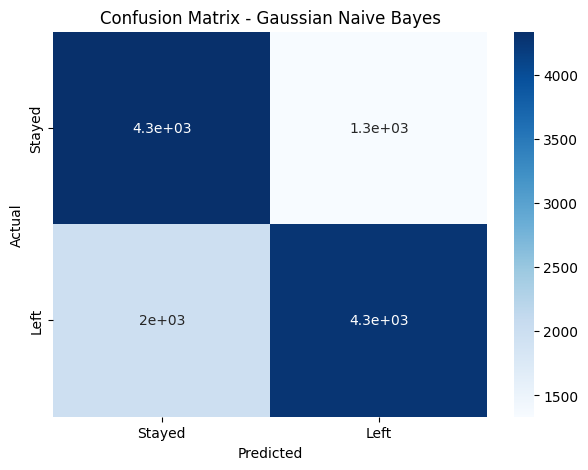

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(cm_nb, annot= True, cmap= 'Blues',
            xticklabels= ['Stayed', 'Left'],
            yticklabels= ['Stayed', 'Left'])

plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 14. Classification Report

Generate a detailed classification report for the baseline Gaussian Naive Bayes model, including precision, recall, F1-score, and support for each class.

In [ ]:
print('Classification Report - Gaussian Naive Bayes')
print('=' * 60)

print(
    classification_report(y_test, y_pred_nb,
                          labels= ['Stayed', 'Left'],
                          target_names = ['Stayed', 'Left'])
)

Classification Report - Gaussian Naive Bayes
              precision    recall  f1-score   support

      Stayed       0.76      0.68      0.72      6252
        Left       0.69      0.76      0.72      5668

    accuracy                           0.72     11920
   macro avg       0.72      0.72      0.72     11920
weighted avg       0.73      0.72      0.72     11920



# 15. ROC-AUC Score

Evaluate the baseline Gaussian Naive Bayes model using prediction probabilities and calculate the ROC-AUC score.

In [ ]:
# Get prediction probabilities
y_prob_nb = nb_pipeline.predict_proba(X_test)

# Find the probability column corresponding to 'Left'
left_index = list(nb_pipeline.classes_).index('Left')

# Probability of Left
y_prob_left = y_prob_nb[:, left_index]

# Convert actual target to binary
# Stayed = 0
# Left = 1
y_test_binary = (y_test == 'Left').astype(int)

# Calculate ROC-AUC
roc_auc_nb = roc_auc_score(
    y_test_binary,
    y_prob_left
)

print("Baseline Naive Bayes ROC-AUC")
print("=" * 45)
print(f"ROC-AUC : {roc_auc_nb:.4f}")

Baseline Naive Bayes ROC-AUC
ROC-AUC : 0.8048


# Step 16. ROC Curve

Visualize the ROC curve of the baseline Gaussian Naive Bayes model and display its ROC-AUC score.

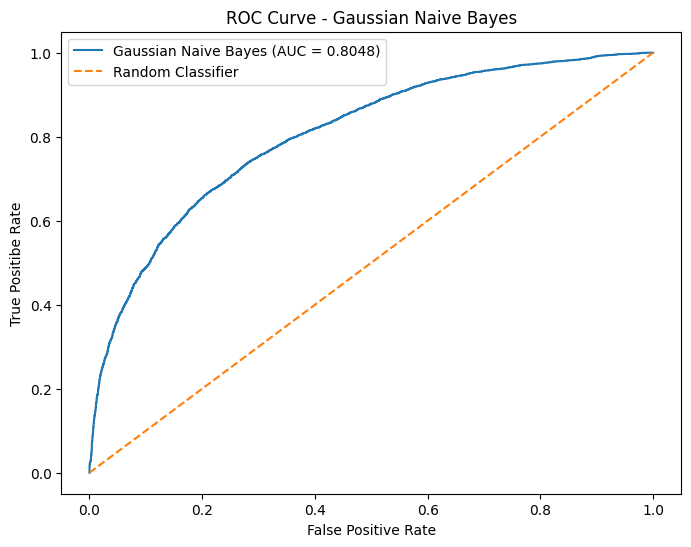

In [ ]:
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test_binary, y_prob_left)

plt.figure(figsize=(8,6))
plt.plot(fpr_nb, tpr_nb, label= f'Gaussian Naive Bayes (AUC = {roc_auc_nb:.4f})')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle= '--',
    label= 'Random Classifier'
)
plt.title('ROC Curve - Gaussian Naive Bayes')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positibe Rate')
plt.legend()
plt.show()

# 17. Hyperparameter Tuning

Tune the Gaussian Naive Bayes model using GridSearchCV and identify the best value of var_smoothing based on F1 score.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Create F1 scorer with 'Left' as the positive class
f1_left_scorer = make_scorer(
    f1_score,
    pos_label='Left'
)

# Parameter grid
param_grid_nb = {
    'nb__var_smoothing': [
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5
    ]
}

# GridSearchCV
grid_nb = GridSearchCV(
    estimator = nb_pipeline,
    param_grid = param_grid_nb,
    scoring = f1_left_scorer,
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

# Train GridSearchCV
grid_nb.fit(X_train, y_train)

print("Naive Bayes Hyperparameter Tuning Completed")
print("=" * 50)

print("Best Parameters:")
print(grid_nb.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_nb.best_score_:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Naive Bayes Hyperparameter Tuning Completed
Best Parameters:
{'nb__var_smoothing': 1e-11}

Best Cross-Validation F1 Score:
0.7235


# Step 18 — Tuned Naive Bayes predictions

In [ ]:
# Tuned Naive Bayes Predictions

y_pred_tuned = grid_nb.predict(X_test)

print("Tuned Naive Bayes Predictions Generated")
print("=" * 50)
print("Number of Predictions:", len(y_pred_tuned))
print("First 20 Predictions:", y_pred_tuned[:20])

Tuned Naive Bayes Predictions Generated
Number of Predictions: 11920
First 20 Predictions: ['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Left' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Left']


# 19. Tuned Naive Bayes Evaluation

Evaluate the tuned Gaussian Naive Bayes model on the unseen test dataset using accuracy, precision, recall, and F1-score.

In [ ]:
accuracy_tuned_nb = accuracy_score(y_test, y_pred_tuned)
precision_tuned_nb = precision_score(y_test, y_pred_tuned, pos_label= 'Left')
recall_tuned_nb = recall_score(y_test, y_pred_tuned, pos_label= 'Left')
f1_tuned_nb = f1_score(y_test, y_pred_tuned, pos_label= 'Left')

print('Tuned Naive Bayes Performance')
print('=' * 50)

print(f'Accuracy : {accuracy_tuned_nb:.4f}')
print(f'Precision : {precision_tuned_nb:.4f}')
print(f'Recall : {recall_tuned_nb:.4f}')
print(f'F1 Score : {f1_tuned_nb:.4f}')

Tuned Naive Bayes Performance
Accuracy : 0.7218
Precision : 0.6862
Recall : 0.7646
F1 Score : 0.7233


# 20. Tuned Naive Bayes ROC-AUC

In [ ]:
y_prob_tuned_nb = grid_nb.predict_proba(X_test)

left_index_tuned = list(grid_nb.classes_).index('Left')

y_prob_tuned_left = y_prob_tuned_nb[:, left_index_tuned]

y_test_binary = (y_test == 'Left').astype(int)

roc_auc_tuned_nb = roc_auc_score(
    y_test_binary,
    y_prob_tuned_left
)

print("Tuned Naive Bayes ROC-AUC")
print("=" * 45)
print(f"ROC-AUC : {roc_auc_tuned_nb:.4f}")

Tuned Naive Bayes ROC-AUC
ROC-AUC : 0.8048


# 21. Tuned Naive Bayes Confusion Matrix

In [ ]:
cm_tuned_nb = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=['Stayed', 'Left']
)

print("Tuned Naive Bayes Confusion Matrix")
print("=" * 50)
print(cm_tuned_nb)

Tuned Naive Bayes Confusion Matrix
[[4270 1982]
 [1334 4334]]


# 22. Tuned Naive Bayes Classification Report

In [ ]:
print("Classification Report - Tuned Gaussian Naive Bayes")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_tuned,
        labels=['Stayed', 'Left'],
        target_names=['Stayed', 'Left']
    )
)

Classification Report - Tuned Gaussian Naive Bayes
              precision    recall  f1-score   support

      Stayed       0.76      0.68      0.72      6252
        Left       0.69      0.76      0.72      5668

    accuracy                           0.72     11920
   macro avg       0.72      0.72      0.72     11920
weighted avg       0.73      0.72      0.72     11920



# 23. Baseline vs Tuned Naive Bayes

In [ ]:
nb_comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Baseline Naive Bayes': [
        accuracy_nb,
        precision_nb,
        recall_nb,
        f1_nb,
        roc_auc_nb
    ],
    'Tuned Naive Bayes': [
        accuracy_tuned_nb,
        precision_tuned_nb,
        recall_tuned_nb,
        f1_tuned_nb,
        roc_auc_tuned_nb
    ]
})

print("Baseline vs Tuned Naive Bayes")
print("=" * 60)

display(
    nb_comparison.style.format({
        'Baseline Naive Bayes': '{:.4f}',
        'Tuned Naive Bayes': '{:.4f}'
    })
)

Baseline vs Tuned Naive Bayes


,Metric,Baseline Naive Bayes,Tuned Naive Bayes
0,Accuracy,0.7218,0.7218
1,Precision,0.6862,0.6862
2,Recall,0.7646,0.7646
3,F1 Score,0.7233,0.7233
4,ROC-AUC,0.8048,0.8048


# 24. New Employee for Attrition Prediction

In [ ]:
new_employee = pd.DataFrame([{
    'Age': 30,
    'Gender': 'Male',
    'Years at Company': 5,
    'Job Role': 'Technology',
    'Monthly Income': 6000,
    'Work-Life Balance': 'Good',
    'Job Satisfaction': 'High',
    'Performance Rating': 'High',
    'Number of Promotions': 1,
    'Overtime': 'No',
    'Distance from Home': 10,
    'Education Level': 'Bachelor’s Degree',
    'Marital Status': 'Married',
    'Number of Dependents': 2,
    'Job Level': 'Mid',
    'Company Size': 'Medium',
    'Company Tenure': 5,
    'Remote Work': 'Yes',
    'Leadership Opportunities': 'Yes',
    'Innovation Opportunities': 'Yes',
    'Company Reputation': 'Good',
    'Employee Recognition': 'High'
}])

print("New Employee Data:")
display(new_employee)

New Employee Data:


,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition
0,30,Male,5,Technology,6000,Good,High,High,1,No,...,Married,2,Mid,Medium,5,Yes,Yes,Yes,Good,High


# 25. Naive Bayes Employee Attrition Prediction

In [ ]:
best_nb_model = grid_nb.best_estimator_

prediction_nb = best_nb_model.predict(new_employee)

probabilities_nb = best_nb_model.predict_proba(new_employee)

print("New Employee Attrition Prediction")
print("=" * 50)

print(f"Prediction : {prediction_nb[0]}")

print("\nPrediction Probabilities:")

for class_name, probability in zip(
    best_nb_model.classes_,
    probabilities_nb[0]
):
    print(f"{class_name} : {probability * 100:.4f}%")

New Employee Attrition Prediction
Prediction : Stayed

Prediction Probabilities:
Left : 0.0029%
Stayed : 99.9971%


# 26. Save Final Tuned Naive Bayes Model

In [ ]:
import joblib

model_filename = "Employee_Attrition_Naive_Bayes_Model.pkl"

joblib.dump(grid_nb, model_filename)

print(f"Model Saved Successfully as : {model_filename}")

Model Saved Successfully as : Employee_Attrition_Naive_Bayes_Model.pkl


# 27. Load Saved Naive Bayes Model

In [ ]:
import joblib

loaded_nb_model = joblib.load(
    "Employee_Attrition_Naive_Bayes_Model.pkl"
)

print("Naive Bayes Model Loaded Successfully")

Naive Bayes Model Loaded Successfully


# 28. Prediction Using Loaded Naive Bayes Model

In [ ]:
loaded_prediction_nb = loaded_nb_model.predict(new_employee)[0]

loaded_probabilities_nb = loaded_nb_model.predict_proba(new_employee)[0]

loaded_classes_nb = loaded_nb_model.classes_

print("Loaded Naive Bayes Model Prediction")
print("=" * 50)

print(f"Prediction : {loaded_prediction_nb}")

print("\nPrediction Probabilities:")

for class_name, probability in zip(
    loaded_classes_nb,
    loaded_probabilities_nb
):
    print(f"{class_name} : {probability * 100:.4f}%")

Loaded Naive Bayes Model Prediction
Prediction : Stayed

Prediction Probabilities:
Left : 0.0029%
Stayed : 99.9971%
